In [1]:
import basedosdados as bd
import pandas as pd

In [151]:
project_id = "teste-ic-fairness"
query = """
SELECT
  d.id_inscricao,
  d.cor_raca,
  d.ensino,
  d.estado_civil,
  d.nota_matematica,
  d.nota_ciencias_natureza,
  d.nota_ciencias_humanas,
  d.nota_linguagens_codigos,
  d.sexo,
  d.sigla_uf_prova,
  d.tipo_escola,
  q.q006 AS renda_familiar,
  q.q025 AS tem_internet,
FROM
  `basedosdados.br_inep_enem.microdados` as d

INNER JOIN `basedosdados.br_inep_enem.questionario_socioeconomico_2023` as q
  ON q.id_inscricao = d.id_inscricao

WHERE d.ano = 2023
AND d.nota_matematica IS NOT NULL
AND d.ensino IS NOT NULL
AND d.sigla_uf_prova IS NOT NULL
LIMIT 200000;
"""

#df = bd.read_sql(query, billing_project_id=project_id)
#df.to_csv('dataset.csv', index=False)

import os
import matplotlib.pyplot as plt

df = pd.read_csv('dataset.csv')

PROJECT_ROOT_DIR = '.'
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images")
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

print(df)


        id_inscricao  cor_raca  ensino  estado_civil  nota_matematica  \
0       210061896559         1       1             1            409.8   
1       210060316901         1       1             1            460.2   
2       210060937029         3       1             1            416.3   
3       210058129257         3       1             1            434.2   
4       210058124963         3       1             1            355.4   
...              ...       ...     ...           ...              ...   
199995  210061827835         2       1             1            457.1   
199996  210061830054         3       1             1            359.2   
199997  210059688368         1       1             1            665.7   
199998  210061683258         2       1             1            395.6   
199999  210061796196         3       1             1            438.1   

        nota_ciencias_natureza  nota_ciencias_humanas  \
0                        461.1                    0.0   
1        

In [3]:
df[df.notnull().all(1)]

,id_inscricao,cor_raca,ensino,estado_civil,nota_matematica,nota_ciencias_natureza,nota_ciencias_humanas,nota_linguagens_codigos,sexo,sigla_uf_prova,tipo_escola,renda_familiar,tem_internet
0,210061896559,1,1,1,409.8,461.1,0.0,0.0,M,PA,2,B,B
1,210060316901,1,1,1,460.2,462.0,0.0,0.0,F,AM,2,B,A
2,210060937029,3,1,1,416.3,501.8,0.0,0.0,M,GO,2,C,B
3,210058129257,3,1,1,434.2,497.0,0.0,0.0,F,AM,2,B,B
4,210058124963,3,1,1,355.4,457.1,0.0,0.0,F,SC,2,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,210061827835,2,1,1,457.1,421.4,427.6,443.6,F,PA,2,B,B
199996,210061830054,3,1,1,359.2,393.5,328.6,414.8,F,MG,2,B,B
199997,210059688368,1,1,1,665.7,491.7,540.9,533.5,F,SC,2,I,B
199998,210061683258,2,1,1,395.6,401.4,449.1,433.9,M,SE,2,A,B


In [4]:
df.head(50)

,id_inscricao,cor_raca,ensino,estado_civil,nota_matematica,nota_ciencias_natureza,nota_ciencias_humanas,nota_linguagens_codigos,sexo,sigla_uf_prova,tipo_escola,renda_familiar,tem_internet
0,210061896559,1,1,1,409.8,461.1,0.0,0.0,M,PA,2,B,B
1,210060316901,1,1,1,460.2,462.0,0.0,0.0,F,AM,2,B,A
2,210060937029,3,1,1,416.3,501.8,0.0,0.0,M,GO,2,C,B
3,210058129257,3,1,1,434.2,497.0,0.0,0.0,F,AM,2,B,B
4,210058124963,3,1,1,355.4,457.1,0.0,0.0,F,SC,2,B,B
5,210059589145,3,1,1,393.2,338.4,0.0,0.0,M,AM,2,B,B
6,210058418995,3,1,1,377.5,336.0,0.0,0.0,M,SP,2,B,B
7,210058404766,3,1,1,422.7,392.2,0.0,0.0,F,BA,2,B,A
8,210059928940,3,1,1,0.0,0.0,0.0,0.0,F,BA,2,B,B
9,210060247988,2,1,1,479.9,472.9,0.0,0.0,F,SP,2,G,B


In [5]:
df.describe()

,id_inscricao,cor_raca,ensino,estado_civil,nota_matematica,nota_ciencias_natureza,nota_ciencias_humanas,nota_linguagens_codigos,tipo_escola
count,2.000000e+05,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,2.100599e+11,2.135375,1.005535,0.976620,502.083378,473.788410,501.490784,499.053181,2.110410
std,1.129876e+06,0.993465,0.074192,0.275107,116.670040,77.904122,88.961932,79.156963,0.313401
min,2.100580e+11,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,2.100588e+11,1.000000,1.000000,1.000000,413.000000,425.100000,450.000000,456.500000,2.000000
50%,2.100599e+11,2.000000,1.000000,1.000000,487.700000,471.600000,509.700000,506.000000,2.000000
75%,2.100608e+11,3.000000,1.000000,1.000000,582.100000,523.800000,560.900000,550.300000,2.000000
max,2.100621e+11,5.000000,2.000000,4.000000,958.600000,868.400000,804.400000,768.900000,3.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id_inscricao             200000 non-null  int64  
 1   cor_raca                 200000 non-null  int64  
 2   ensino                   200000 non-null  int64  
 3   estado_civil             200000 non-null  int64  
 4   nota_matematica          200000 non-null  float64
 5   nota_ciencias_natureza   200000 non-null  float64
 6   nota_ciencias_humanas    200000 non-null  float64
 7   nota_linguagens_codigos  200000 non-null  float64
 8   sexo                     200000 non-null  object 
 9   sigla_uf_prova           200000 non-null  object 
 10  tipo_escola              200000 non-null  int64  
 11  renda_familiar           200000 non-null  object 
 12  tem_internet             200000 non-null  object 
dtypes: float64(4), int64(5), object(4)
memory usage: 19.8+ MB


In [7]:
# Temos alguns valores nulos nas colunas 'nota_ciencias_humanas' e 'nota_linguagens_codigos', então precisamos tratar desses valores
# Eu penso em duas possibilidades para tratar desses valores nulos, ou podemos substituir pela média das notas ou podemos considerar como 0
# Penso que o melhor é substituir com 0, porque se o valor é nulo, muito provavelmente é pq o candidato não foi fazer a prova no dia

# vamos então substituir com 0
null_cols = ['nota_ciencias_humanas', 'nota_linguagens_codigos']
df[null_cols] = df[null_cols].fillna(0, axis=1)
#df.to_csv('dataset.csv', index=False)

In [8]:
df.nunique()

id_inscricao               200000
cor_raca                        6
ensino                          2
estado_civil                    5
nota_matematica              5463
nota_ciencias_natureza       4102
nota_ciencias_humanas        4404
nota_linguagens_codigos      4164
sexo                            2
sigla_uf_prova                 27
tipo_escola                     2
renda_familiar                 17
tem_internet                    2
dtype: int64

In [9]:
mapa_raca = {
    0: 'Não Declarado',
    1: 'Branca',
    2: 'Preta',
    3: 'Parda',
    4: 'Amarela',
    5: 'Indígena'
}

mapa_escola = {
    1: 'Não Respondido',
    2: 'Pública',
    3: 'Privada'
}

mapa_internet = {'A': 'Não', 'B': 'Sim'}

# Substituindo no DataFrame
df_visualizacao = df.copy()
df_visualizacao['cor_raca'] = df_visualizacao['cor_raca'].map(mapa_raca)
df_visualizacao['tipo_escola'] = df_visualizacao['tipo_escola'].map(mapa_escola)
df_visualizacao['tem_internet'] = df_visualizacao['tem_internet'].map(mapa_internet)

df_visualizacao.head(10)

# Esse dataFrame facilita a visualização de alguns dados, como raça, tipo da escola, que são atributos importantes.

,id_inscricao,cor_raca,ensino,estado_civil,nota_matematica,nota_ciencias_natureza,nota_ciencias_humanas,nota_linguagens_codigos,sexo,sigla_uf_prova,tipo_escola,renda_familiar,tem_internet
0,210061896559,Branca,1,1,409.8,461.1,0.0,0.0,M,PA,Pública,B,Sim
1,210060316901,Branca,1,1,460.2,462.0,0.0,0.0,F,AM,Pública,B,Não
2,210060937029,Parda,1,1,416.3,501.8,0.0,0.0,M,GO,Pública,C,Sim
3,210058129257,Parda,1,1,434.2,497.0,0.0,0.0,F,AM,Pública,B,Sim
4,210058124963,Parda,1,1,355.4,457.1,0.0,0.0,F,SC,Pública,B,Sim
5,210059589145,Parda,1,1,393.2,338.4,0.0,0.0,M,AM,Pública,B,Sim
6,210058418995,Parda,1,1,377.5,336.0,0.0,0.0,M,SP,Pública,B,Sim
7,210058404766,Parda,1,1,422.7,392.2,0.0,0.0,F,BA,Pública,B,Não
8,210059928940,Parda,1,1,0.0,0.0,0.0,0.0,F,BA,Pública,B,Sim
9,210060247988,Preta,1,1,479.9,472.9,0.0,0.0,F,SP,Pública,G,Sim


In [10]:
df[df['id_inscricao'].duplicated()]

,id_inscricao,cor_raca,ensino,estado_civil,nota_matematica,nota_ciencias_natureza,nota_ciencias_humanas,nota_linguagens_codigos,sexo,sigla_uf_prova,tipo_escola,renda_familiar,tem_internet


In [11]:
df_visualizacao[df_visualizacao['tipo_escola'] == "Privada"].count()

# podemos ver que a minoria dos alunos é de escola particular (o que seria uma vantagem)

id_inscricao               22082
cor_raca                   22082
ensino                     22082
estado_civil               22082
nota_matematica            22082
nota_ciencias_natureza     22082
nota_ciencias_humanas      22082
nota_linguagens_codigos    22082
sexo                       22082
sigla_uf_prova             22082
tipo_escola                22082
renda_familiar             22082
tem_internet               22082
dtype: int64

In [12]:
dataEscola = df_visualizacao.groupby('tipo_escola')['nota_matematica'].mean().sort_values(ascending=False)
dataEscola

# a privada tem uma média de mais de 100 pontos maior que a pública

tipo_escola
Privada    600.832515
Pública    489.827291
Name: nota_matematica, dtype: float64

In [13]:
dataGender = df_visualizacao.groupby('sexo')['nota_matematica'].mean().sort_values(ascending=False)
dataGender

sexo
M    524.786342
F    489.438061
Name: nota_matematica, dtype: float64

In [14]:
dataRenda = df_visualizacao.groupby('renda_familiar')['nota_matematica'].mean().sort_values(ascending=False)
dataRenda

# rendas maiores tendém a irem melhores. A renda Q (> 20 sslários minímos) tem o segundo maior máximo e a maior média
# enquanto a renda A (sem renda) tem a pior média e máxima

renda_familiar
Q    672.705565
P    665.090043
O    643.610971
N    636.146320
M    620.943582
L    618.256348
K    603.145721
J    595.996427
I    582.197802
H    573.264115
G    554.574519
F    544.651185
E    525.957401
D    514.496704
C    501.015249
B    469.239978
A    445.804017
Name: nota_matematica, dtype: float64

In [15]:
dataRace = df_visualizacao.groupby('cor_raca')['nota_matematica'].mean().sort_values(ascending=False)
dataRace

cor_raca
Branca           531.212043
Não Declarado    491.982355
Parda            487.774064
Amarela          483.049020
Preta            479.286849
Indígena         448.434475
Name: nota_matematica, dtype: float64

In [16]:
dataState = df_visualizacao.groupby('sigla_uf_prova')['nota_matematica'].mean().sort_values(ascending=False)
dataState

sigla_uf_prova
DF    542.024810
ES    539.460030
MG    525.568500
SP    521.706806
RS    521.216694
SC    514.012454
PR    512.495829
RJ    507.502274
CE    501.042874
BA    500.303355
GO    500.121834
AL    498.383391
PE    493.921453
MS    491.192525
AC    490.149383
PB    485.742944
RO    485.145636
MT    484.934705
RR    484.265074
RN    483.521936
AP    478.345564
SE    478.122947
AM    474.645349
TO    474.103057
PI    471.157426
PA    466.486350
MA    458.691971
Name: nota_matematica, dtype: float64

In [17]:
dataNet = df_visualizacao.groupby('tem_internet')['nota_matematica'].mean().sort_values(ascending=False)
dataNet

tem_internet
Sim    507.648771
Não    456.634585
Name: nota_matematica, dtype: float64

#### Regressão

Vamos começar com um modelo de Regressão para tentar prever (ou aproximar) a nota da prova de matemática de um aluno que participou do ENEM no ano de 2023. 
<br><br>
O target Y, logicamente, é a nota na prova de matemática.<br>
As outras colunas representam os features (exceto id_inscricao)

Vamos começar com um modelo simples, como um Linear Regression.\
<b>Ainda não iremos calcular métricas de fairness</b>.

In [265]:
# Como no dataset temos diversos valores que são strings, posso usar OneHot Encoder para alguns features com poucas opções, como genero,
# tipo_escola, tem_internet e ensinom que possuem apenas 2 opções
# Para atributos progressivos como renda familiar, podemos considerar um Ordinal Encoder.

# Para atributos como a renda, que possui diversas categorias, talvez um TargetEncoder possa ser útil

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

import numpy as np

np.random.seed(42)

X = df.drop(['nota_matematica', 'id_inscricao'], axis=1)
y = df['nota_matematica']

label_values = ['renda_familiar']
oh_values = ['tipo_escola', 'tem_internet', 'sexo', 'ensino', 'cor_raca', 'estado_civil', 'sigla_uf_prova']
numeric_values = ['nota_ciencias_natureza', 'nota_ciencias_humanas', 'nota_linguagens_codigos']
# target_encoder_values = []

full_pipeline = ColumnTransformer(
    transformers=[
        ('label_val', OrdinalEncoder(), label_values),
        ('oh', OneHotEncoder(handle_unknown='ignore'), oh_values),
        ('num', StandardScaler(), numeric_values)
    ],
    remainder='drop',
)

# linear_regression_model_pipeline = Pipeline([
#     ('preprocessor', full_pipeline),
#     ('model', LinearRegression()),
# ])

# splitDf = KFold(random_state=42, shuffle=True)

# total_mae = 0
# total_rmse = 0
# total_r2 = 0
# for i, (train_index, test_index) in enumerate(splitDf.split(X)):
#     X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#     y_train, y_test = y.iloc[train_index], y.iloc[test_index]

#     linear_regression_model_pipeline.fit(X_train, y_train)

#     # print(f"Treinando no fold {i + 1}")

#     preds = linear_regression_model_pipeline.predict(X_test)

#     mae = mean_absolute_error(y_test, preds)
#     total_mae += mae
#     # print(f"MAE no fold {i + 1}: {mae}")

#     rmse = root_mean_squared_error(y_test, preds)
#     total_rmse += rmse
#     # print(f"RMSE no fold {i + 1}: {rmse}")

#     r2 = r2_score(y_test, preds)
#     total_r2 += r2
#     # print(f"R2 no fold {i + 1}: {r2}")


# print(f"\nMédia geral do MAE: {total_mae / 5}")
# print(f"Média geral do RMSE: {total_rmse / 5}")
# print(f"Média geral do R2: {total_r2 / 5}")

In [175]:
X

,cor_raca,ensino,estado_civil,nota_ciencias_natureza,nota_ciencias_humanas,nota_linguagens_codigos,sexo,sigla_uf_prova,tipo_escola,renda_familiar,tem_internet
0,1,1,1,461.1,0.0,0.0,M,PA,2,B,B
1,1,1,1,462.0,0.0,0.0,F,AM,2,B,A
2,3,1,1,501.8,0.0,0.0,M,GO,2,C,B
3,3,1,1,497.0,0.0,0.0,F,AM,2,B,B
4,3,1,1,457.1,0.0,0.0,F,SC,2,B,B
...,...,...,...,...,...,...,...,...,...,...,...
199995,2,1,1,421.4,427.6,443.6,F,PA,2,B,B
199996,3,1,1,393.5,328.6,414.8,F,MG,2,B,B
199997,1,1,1,491.7,540.9,533.5,F,SC,2,I,B
199998,2,1,1,401.4,449.1,433.9,M,SE,2,A,B


In [20]:
# random_forest_full_pipeline = Pipeline([
#     ('preprocessor', full_pipeline),
#     ('model', RandomForestRegressor(
#         n_estimators=1000,
#         max_features=75,
#         max_depth=5
#     )),
# ])

# total_mae = 0
# total_rmse = 0
# total_r2 = 0
# for i, (train_index, test_index) in enumerate(splitDf.split(X)):
#     X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#     y_train, y_test = y.iloc[train_index], y.iloc[test_index]

#     random_forest_full_pipeline.fit(X_train, y_train)

#     # print(f"Treinando no fold {i + 1}")

#     preds = random_forest_full_pipeline.predict(X_test)

#     mae = mean_absolute_error(y_test, preds)
#     total_mae += mae
#     # print(f"MAE no fold {i + 1}: {mae}")

#     rmse = root_mean_squared_error(y_test, preds)
#     total_rmse += rmse
#     # print(f"RMSE no fold {i + 1}: {rmse}")

#     r2 = r2_score(y_test, preds)
#     total_r2 += r2
#     # print(f"R2 no fold {i + 1}: {r2}")


# print(f"\nMédia geral do MAE: {total_mae / 5}")
# print(f"Média geral do RMSE: {total_rmse / 5}")
# print(f"Média geral do R2: {total_r2 / 5}")

In [21]:
# param_grid = {
#     'model__n_estimators': [200, 500, 1000],
#     'model__max_features': [50, 75],
#     'model__max_depth': [5, 8, 10]
# }

# grid_search = GridSearchCV(random_forest_full_pipeline, param_grid, cv=splitDf, scoring='r2', return_train_score=True)
# grid_search.fit(X_train, y_train)

In [22]:
# # def evaluate_sub_groups_for_regression(df, y_true, y_pred, X):
# for coluna in X.columns:
#     print(f"Analisando coluna: {coluna}")
#     for grupo, sub_df in df.groupby(coluna):
#         mae_grupo = mean_absolute_error(y_test, preds)
#         rmse_grupo = root_mean_squared_error(y_test, preds)
#         print(f"Grupo {grupo} | Qtd Alunos: {len(sub_df)} \t | MAE: {mae_grupo:.2f} | RMSE: {rmse_grupo:.2f}")
#     print()

# evaluate_sub_groups_for_regression(df, y_true, )

In [23]:
"""
Os resultados até aqui obtidos são curiosos.
Um modelo LinearRegression teve uma performance semelhante (ou até melhor) que um modelo como Random Forest, que é teoricamente mais poderoso
e capaz de encontrar relações mais profundas nos dados. Porque isso acontece?


Podemos ver também que mesmo eles tendo um resultado semelhante, esse resultado não é muito bom. Um MAE de aproximadamente 80 para notas é
considerávelmente alto, dado que uma variação de 80 pontos em matemática pode definir se o aluno passa ou não.
Mas quando estamos focando em fairness, nem sempre queremos o modelo com maior precisão, mas sim o mais justo, por isso é importante atestar esse
modelo contra métricas de fairness.


Outra coisa é também a diferença de performance para alguns grupos. Eu notei algo contraditório, por exemplo:
    Vamos analisar a coluna "tem_internet". 3590 alunos tem acesso a internet e 410 não tem. Então, o grupo que possui internet está mais bem representado.
    Eu pensei que grupos que são menos representados normalmente tivessem um score/precisão menor, justamente porque são menos representados e, consequentemente
    o modelo não concebe tão bem as relações e padrões entre os membros desse grupo.
    Entretanto, o contrário acontece aqui, os 410 alunos que não possuem acesso a internet tem um MAE e RMSE menor do que os que tem. Porque isso acontece?
    Essa é provavelmente minha maior dúvida até agora, juntamente com a semelhança de resultados entre LR e RF.

    Pesquisando sobre o primeiro tópico (performance dos grupos bem/mal representados), achei uma que pode ser uma boa explicação para o que acontece aqui.
    Pegando o mesmo exemplo da coluna "tem_internet", é notório que a internet é um bem um tanto quanto acessível atualmente, então os 3590 alunos que estão no grupo B
    provavelmente estão espalhados por diversas classes sociais, indo de classe baixa para classe alta, então temos uma grande variação de alunos, o que torna
    a previsão indivídual mais difícil.
    Já o grupo A contempla aqueles que não possuem internet, que são muito provavelmente de uma classe social mais vulnerável, como pessoas com uma
    renda muito pequena ou até mesmo sem nenhuma renda. Portanto, é muito provável que as pessoas nesse grupo tenham uma nota menor, a homogeniedade nesse grupo é maior,
    fazendo com que seja mais fácil fazer uma previsão para esse grupo, mesmo com uma menor representação.
"""

'\nOs resultados até aqui obtidos são curiosos.\nUm modelo LinearRegression teve uma performance semelhante (ou até melhor) que um modelo como Random Forest, que é teoricamente mais poderoso\ne capaz de encontrar relações mais profundas nos dados. Porque isso acontece?\n\n\nPodemos ver também que mesmo eles tendo um resultado semelhante, esse resultado não é muito bom. Um MAE de aproximadamente 80 para notas é\nconsiderávelmente alto, dado que uma variação de 80 pontos em matemática pode definir se o aluno passa ou não.\nMas quando estamos focando em fairness, nem sempre queremos o modelo com maior precisão, mas sim o mais justo, por isso é importante atestar esse\nmodelo contra métricas de fairness.\n\n\nOutra coisa é também a diferença de performance para alguns grupos. Eu notei algo contraditório, por exemplo:\n    Vamos analisar a coluna "tem_internet". 3590 alunos tem acesso a internet e 410 não tem. Então, o grupo que possui internet está mais bem representado.\n    Eu pensei que

In [176]:
# Vamos agora transformar isso em um problema de classificação

# df['nota_matematica'].mean() -> 495 foi a média das notas de matemática no ENEM 2023, vou arrendodar para 500

y_classificacao = (df['nota_matematica'] >= 500).astype(int) # transforma em binário, 0 ou 1
y_classificacao.value_counts() # considerando o mínimo para passar em 500, temos mais pessoas reprovadas do que aprovadas

nota_matematica
0    107455
1     92545
Name: count, dtype: int64

In [216]:
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_curve,
    auc,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
    roc_curve)
from sklearn.model_selection import cross_val_score
import joblib

# classifier_model1_pipeline = Pipeline([
#     ('preprocessor', full_pipeline),
#     ('model', SGDClassifier(loss='modified_huber'))
# ])

classifier1 = joblib.load('models/sgdClassifier-1.joblib')

# classifier_model2_pipeline = Pipeline([
#     ('preprocessor', full_pipeline),
#     ('model', RandomForestClassifier())
# ])


In [ ]:
def train_model(model):
    kfolds = KFold(n_splits=5)
    for i, (train_index, test_index) in enumerate(kfolds.split(X)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y_classificacao.iloc[train_index], y_classificacao.iloc[test_index]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        n_correct = sum(y_pred == y_test)
        print(n_correct / len(y_pred))

# train_model(classifier1)


# scores = cross_val_score(classifier_model1_pipeline, X_train, y_train, cv=3, scoring='accuracy')
# print(f"\ncross_val_score: {scores}\n")
# train_and_evaluate_model(classifier_model2_pipeline, 'accuracy')

# df_analise = X_test.copy()
# df_analise['real'] = y_test
# df_analise['pred'] = y_pred

0.7505
0.7505
0.744375
0.766225
0.767725


In [217]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(classifier1, X, y_classificacao, cv=3)

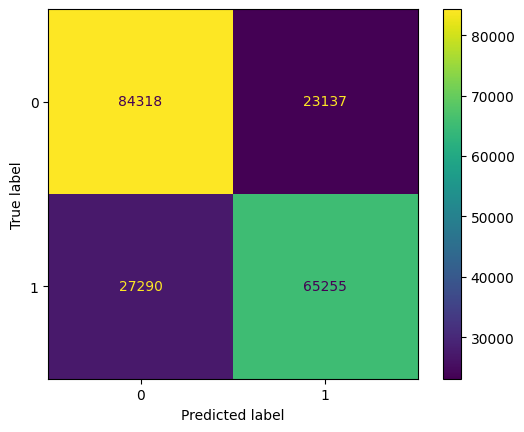

In [218]:
# confusion_matrix(y_train, y_train_pred)
ConfusionMatrixDisplay.from_predictions(y_classificacao, y_train_pred)

In [219]:
precision_score(y_classificacao, y_train_pred)

0.7382455425830392

In [220]:
recall_score(y_classificacao, y_train_pred)

0.7051164298449403

In [221]:
f1_score(y_classificacao, y_train_pred)

0.7213007842508719

In [212]:
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    equalized_odds_difference,
    demographic_parity_difference,
    false_positive_rate,
    false_negative_rate,
)

df_fairness = X

# False negative: quando a pessoa passou mas o modelo faz a previsão que não passou
# False positive: quando a pessoa não passou mas o modelo faz a previsão que passou.

METRICS = {
    'Accuracy': accuracy_score,
    'Precision': precision_score,
    'Recall': recall_score,
    'Selection Rate (>= 500)': selection_rate,
    'False Positive Rate': false_positive_rate,
    'False Negative Rate': false_negative_rate,
}

SUBGROUPS = [
    'cor_raca',
    'sexo',
]

def calculate_metrics_for_group(metrics, df, group, y, preds):
    metric_frame_generic = MetricFrame(
        metrics=metrics,
        y_true=y,
        y_pred=preds,
        sensitive_features=df[group]
    )

    return metric_frame_generic

def plot_metrics(metric_frame: MetricFrame):
    metric_frame.by_group.plot.bar(
        subplots=True,
        layout=[3,3],
        legend=False,
        figsize=[16, 10]
    )

def calculate_metrics_for_subgroups(metrics, df, subgroup, y, preds):
    for group in subgroup:
        metricas = calculate_metrics_for_group(metrics, df, group, y, preds)
        print(metricas.by_group)

# metric_frame_raca = MetricFrame(
#     metrics=metrics,
#     y_true=y_classificacao,
#     y_pred=y_train_pred,
#     sensitive_features=df_fairness['cor_raca']
# )

# metric_frame_genero = MetricFrame(
#     metrics=metrics,
#     y_true=y_classificacao,
#     y_pred=y_train_pred,
#     sensitive_features=df_fairness['sexo']
# )

# metric_frame_uf = MetricFrame(
#     metrics=metrics,
#     y_true=y_classificacao,
#     y_pred=y_train_pred,
#     sensitive_features=df_fairness['sigla_uf_prova']
# )

# print(metric_frame_raca.by_group)
# print(metric_frame_genero.by_group)
# print(metric_frame_uf.by_group)

calculate_metrics_for_subgroups(METRICS, df_fairness, SUBGROUPS, y_classificacao, y_train_pred)
"""
Analisando os resultados deste modelo sem nenhum tipo de otimização, vemos que a accuracy e o precision são de alguma forma bem distribuídos entre os subgrupos de raça,
contudo, o recall, o selection rate, o FPR e o FNR possuem bias.
    O selection rate é muito maior para pessoas brancas, assim como o FPR. O FPR é maior para pessoas negras, pardas e indígenas, o que significa que o modelo erra mais contra esses
    grupos do que para pessoas brancas. Já o FPR indica que o modelo erra mais a favor de pessoas brancas do que para os demais grupos.
"""

          Accuracy  Precision    Recall  Selection Rate (>= 500)  \
cor_raca                                                           
0         0.768110   0.766857  0.645192                 0.354108   
1         0.754133   0.783592  0.783077                 0.567202   
2         0.752828   0.721331  0.585037                 0.312755   
3         0.755622   0.734736  0.632832                 0.353373   
4         0.766819   0.759280  0.574468                 0.290333   
5         0.798105   0.716216  0.426273                 0.161808   

          False Positive Rate  False Negative Rate  
cor_raca                                            
0                    0.142558             0.354808  
1                    0.283857             0.216923  
2                    0.141857             0.414963  
3                    0.158951             0.367168  
4                    0.113408             0.425532  
5                    0.063063             0.573727  
      Accuracy  Precision    Re

'\nAnalisando os resultados deste modelo sem nenhum tipo de otimização, vemos que a accuracy e o precision são de alguma forma bem distribuídos entre os subgrupos de raça,\ncontudo, o recall, o selection rate, o FPR e o FNR possuem bias.\n    O selection rate é muito maior para pessoas brancas, assim como o FPR. O FPR é maior para pessoas negras, pardas e indígenas, o que significa que o modelo erra mais contra esses\n    grupos do que para pessoas brancas. Já o FPR indica que o modelo erra mais a favor de pessoas brancas do que para os demais grupos.\n'

In [222]:
dp_diff_raca = demographic_parity_difference(y_classificacao, y_train_pred, sensitive_features=df_fairness['cor_raca'])
eo_diff_raca = equalized_odds_difference(y_classificacao, y_train_pred, sensitive_features=df_fairness['cor_raca'])

print(f"Demographic Parity Difference: {dp_diff_raca:.4f}")
print(f"Equalized Odds Difference: {eo_diff_raca:.4f}")

Demographic Parity Difference: 0.4056
Equalized Odds Difference: 0.3206


Agora vou começar o processo de otimização do modelo. 
A primeira coisa que fiz foi obter mais dados, entre eles as demais notas (exceto redação) e dobrar a quantidade de linhas para 20.000, de forma que é possível ter uma representação maior de diferentes grupos.

Treinando o modelo novamente depois dessas mudanças, vi que o precision e o recall aumentaram, o que é um ponto positivo, e também que as métricas de fairness diminuiram (quanto mais próximo de 0, melhor). Então esse é um bom caminho a seguir.

Mas analisando as métricas de fairness para cada estado, vemos algo estranho, para os estados MG, RJ, PR e MA possuem dados muito estranhos, principalmente o FPR e o FNR.

Algo que pode estar causando isso é o desbalanceamento das notas pelos estados, então aumentei ainda mais a qnt de linhas importadas, agora para 200.000.
Fazendo isso vi que as métricas de classificação melhoraram, incluindo: precision, recall, f1. E as métricas separados por grupo normalizaram, como a dos estados.
Contudo, a Demographic Parity Difference e a Equalized Odds aumentaram, o que é ruim.

In [ ]:
#joblib.dump(classifier_model1_pipeline, 'models/sgdClassifier-1.joblib') #-> salva o primeiro modelo sem nenhuma otimização

['models/sgdClassifier-1.joblib']

Saving figure precision-vs-recall


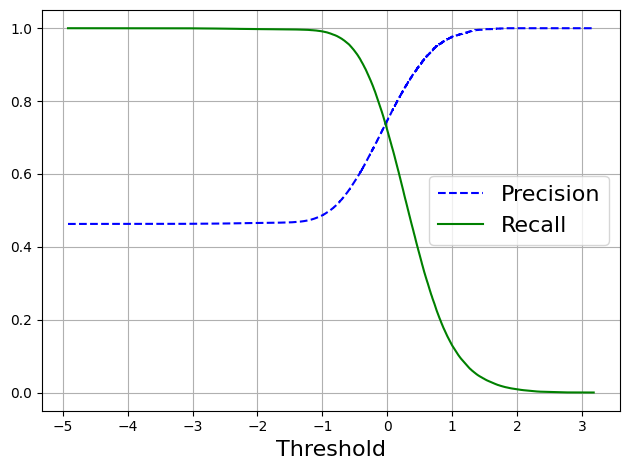

In [223]:
# Ainda na fase de melhoria das métricas de classificação, vamos tentar melhorar nosso modelo para precision
from matplotlib import pyplot as plt

y_train_pred = cross_val_predict(classifier1, X, y_classificacao, cv=3, method='decision_function')
precisions, recalls, thresholds = precision_recall_curve(y_classificacao, y_train_pred)

def plot_precision_recall_curve(p, r, t):
    plt.plot(t, p[:-1], "b--", label="Precision")
    plt.plot(t, r[:-1], "g-", label="Recall")
    plt.legend(loc="center right", fontsize=16) # Not shown in the book
    plt.xlabel("Threshold", fontsize=16)        # Not shown
    plt.grid(True)                              # Not shown

plot_precision_recall_curve(precisions, recalls, thresholds)

save_fig("precision-vs-recall")
plt.show()

In [224]:
threshold_80_precision = thresholds[np.argmax(precisions >= 0.80)]
threshold_80_precision

np.float64(0.1542231003992962)

In [225]:
# new_preds = (classifier_model1_pipeline.predict_proba(X)[:, 1] > threshold_90_precision).astype(int)
new_preds_80 = (y_train_pred >= threshold_80_precision)

In [226]:
print(precision_score(y_classificacao, new_preds_80))
print(recall_score(y_classificacao, new_preds_80))

0.8000027959905496
0.6183478307850235


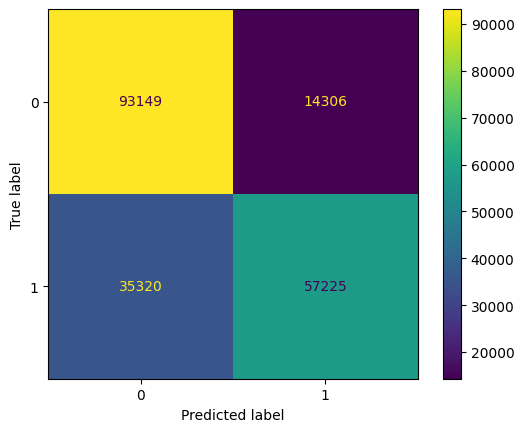

In [227]:
ConfusionMatrixDisplay.from_predictions(y_classificacao, new_preds_80)

In [228]:
calculate_metrics_for_subgroups(METRICS, df_fairness, SUBGROUPS, y_classificacao, new_preds_80)
"""
Otimizando o modelo para precision, notamos que a acurácio diminiui levemente, o precision aumentou,
o recall diminuiu, o selection rate diminiui, o FPR diminiu (modelo erra menos a favor dos grupos) e o FPR
aumentou.

Aqui podemos avaliar bem o trade-off entre precisão e fairness. Ao otimizar o modelo para ter 80% de precisão, vemos que
ele tem uma taxa menor de falsos positivos, que é quando o modelo diz que a pessoa passou mas na realidade não passou, então ele erra
menos a favor. Isso acontece porque forçamos sua precisão pra 80%, então o modelo só diz que alguém passou quando tem quase certeza.
Mas em contrapartida, a taxa de falsos negativos aumentou consideravelmente, principalmente para grupos minoritários.
"""

          Accuracy  Precision    Recall  Selection Rate (>= 500)  \
cor_raca                                                           
0         0.765682   0.797419  0.594231                 0.313638   
1         0.748912   0.822333  0.711289                 0.490932   
2         0.751282   0.763962  0.513741                 0.259315   
3         0.753212   0.780752  0.554077                 0.291161   
4         0.757348   0.793478  0.497021                 0.240366   
5         0.790087   0.737430  0.353887                 0.130466   

          False Positive Rate  False Negative Rate  
cor_raca                                            
0                    0.109713             0.405769  
1                    0.201706             0.288711  
2                    0.099626             0.486259  
3                    0.108248             0.445923  
4                    0.080551             0.502979  
5                    0.047047             0.646113  
      Accuracy  Precision    Re

'\nOtimizando o modelo para precision, notamos que a acurácio diminiui levemente, o precision aumentou,\no recall diminuiu, o selection rate diminiui, o FPR diminiu (modelo erra menos a favor dos grupos) e o FPR\naumentou.\n\nAqui podemos avaliar bem o trade-off entre precisão e fairness. Ao otimizar o modelo para ter 80% de precisão, vemos que\nele tem uma taxa menor de falsos positivos, que é quando o modelo diz que a pessoa passou mas na realidade não passou, então ele erra\nmenos a favor. Isso acontece porque forçamos sua precisão pra 80%, então o modelo só diz que alguém passou quando tem quase certeza.\nMas em contrapartida, a taxa de falsos negativos aumentou consideravelmente, principalmente para grupos minoritários.\n'

In [ ]:
from sklearn.model_selection import FixedThresholdClassifier
from sklearn.frozen import FrozenEstimator

# FixedThresholdClassifier() -> aplica uma threshold específica definida pelo usuário
# TunedThresholdClassifier() -> aplica cross-validation para encontrar o threshold que maximiza alguma métrica

def change_clf_threshold(wrapped_model, new_threshold):
    wrapper = FrozenEstimator(wrapped_model) # o FrozenEstimator() previne refitting do modelo

    new_model = FixedThresholdClassifier(
        estimator=wrapper,
        threshold=new_threshold,
        response_method='predict_proba'
    ) # O modelo é basicamente o mesmo mas com um novo threshold de 80% de precisão

    train_model(new_model)
    return new_model

# classifier1_80p = change_clf_threshold(classifier1, threshold_80_precision)

# joblib.dump(classifier1_80p, 'models/sgdClassifier-2(80).joblib') #-> salva o modelo otimizado para 80% de precisão

0.61595
0.621725
0.6236
0.635725
0.65215


['models/sgdClassifier-2(80).joblib']

Nesse momento, poderiamos continuar tendo otimizar o modelo, como seus hyperparameters via GridSearch ou até testar outros modelos, como
RandomForest, XGBoost, SVMs, etc. 

Porém, como demonstrado mais acima, o trade-off entre precisão/acurácia é nítido e como o foco é desenvolver um modelo 'unbiased', vamos aplicar métricas de fairness. 
Irei aplicar métricas de fairness em todas as etapas do ML Workflow, indo de PreProcessing a InProcessing e por último PostProcessing.

### PreProcessing

In [231]:
# A ideia central do PreProcessing é remover o bias do próprio dataset, evitando que o modelo tenha acesso a dados enviesados
# Existem várias ferramentas/bibliotecas que fornecem soluções para mitigação de bias, vou começar com o fairlearn.

y_train_pred = cross_val_predict(classifier1, X, y_classificacao, cv=3)

metrics_for_race = calculate_metrics_for_group(METRICS, df_fairness, 'cor_raca', y_classificacao, y_train_pred)
metrics_for_gender = calculate_metrics_for_group(METRICS, df_fairness, 'sexo', y_classificacao, y_train_pred)

# plot_metrics(metrics_for_race)
# save_fig("fairness-metrics-race")

In [235]:
for group in SUBGROUPS:
    dp_diff = demographic_parity_difference(y_classificacao, y_train_pred, sensitive_features=df_fairness[group])
    eo_diff = equalized_odds_difference(y_classificacao, y_train_pred, sensitive_features=df_fairness[group])
    print(f"GRUPO: {group}")
    print(f"Demographic Parity Difference: {dp_diff:.4f}")
    print(f"Equalized Odds Difference: {eo_diff:.4f}")
    print()

GRUPO: cor_raca
Demographic Parity Difference: 0.4014
Equalized Odds Difference: 0.3095

GRUPO: sexo
Demographic Parity Difference: 0.1819
Equalized Odds Difference: 0.1232



Saving figure corr


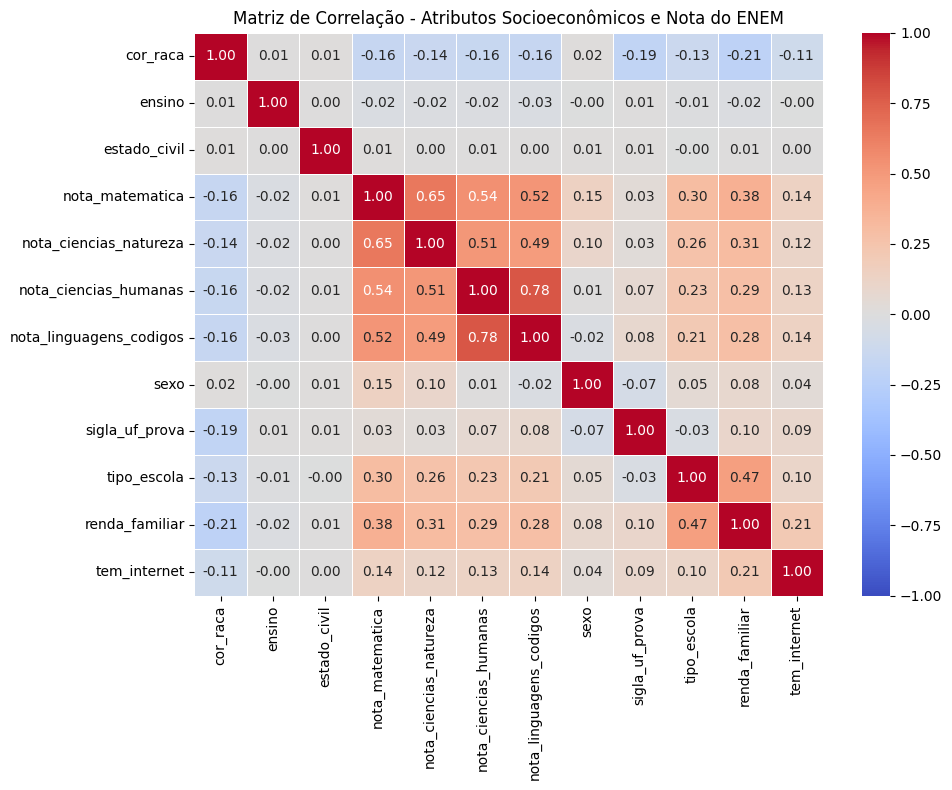

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
import seaborn as sns

df_corr = df.copy()

colunas_categoricas = ['sexo', 'sigla_uf_prova', 'renda_familiar', 'tem_internet']

encoder = OrdinalEncoder()
df_corr[colunas_categoricas] = encoder.fit_transform(df_corr[colunas_categoricas])

if 'id_inscricao' in df_corr.columns:
    df_corr = df_corr.drop('id_inscricao', axis=1)

corr = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title("Matriz de Correlação - Atributos Socioeconômicos e Nota do ENEM")
save_fig("corr")
plt.show()

### PostProcessing

In [274]:
from fairlearn.postprocessing import ThresholdOptimizer, plot_threshold_optimizer

classifier1_optimized = ThresholdOptimizer(
    estimator=classifier1,
    constraints='equalized_odds',
    objective='accuracy_score',
    predict_method='predict_proba'
)

kfolds = KFold(n_splits=5, shuffle=True, random_state=42)
op_preds = np.zeros(len(X))

for i, (train_index, test_index) in enumerate(kfolds.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y_classificacao.iloc[train_index], y_classificacao.iloc[test_index]

    classifier1_optimized.fit(X_train, y_train, sensitive_features=X_train['cor_raca'])

    y_pred = classifier1_optimized.predict(X_test, sensitive_features=X_test['cor_raca'])
    op_preds[test_index] = y_pred

    n_correct = sum(y_pred == y_test)

In [275]:
calculate_metrics_for_subgroups(METRICS, df_fairness, SUBGROUPS, y_classificacao, op_preds)

          Accuracy  Precision    Recall  Selection Rate (>= 500)  \
cor_raca                                                           
0         0.745852   0.706000  0.678846                 0.404694   
1         0.727324   0.813019  0.674762                 0.471057   
2         0.749472   0.675623  0.673839                 0.384598   
3         0.745578   0.695748  0.675095                 0.398097   
4         0.749184   0.672604  0.674894                 0.385042   
5         0.754373   0.541667  0.627346                 0.314869   

          False Positive Rate  False Negative Rate  
cor_raca                                            
0                    0.205451             0.321154  
1                    0.203686             0.325238  
2                    0.203057             0.326161  
3                    0.205387             0.324905  
4                    0.204557             0.325106  
5                    0.198198             0.372654  
      Accuracy  Precision    Re

In [277]:
for group in SUBGROUPS:
    dp_diff = demographic_parity_difference(y_classificacao, op_preds, sensitive_features=df_fairness[group])
    eo_diff = equalized_odds_difference(y_classificacao, op_preds, sensitive_features=df_fairness[group])
    print(f"GRUPO: {group}")
    print(f"Demographic Parity Difference: {dp_diff:.4f}")
    print(f"Equalized Odds Difference: {eo_diff:.4f}")
    print()

GRUPO: cor_raca
Demographic Parity Difference: 0.1562
Equalized Odds Difference: 0.0515

GRUPO: sexo
Demographic Parity Difference: 0.1881
Equalized Odds Difference: 0.1395

